In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [3]:
PROJECT_ROOT = Path("..")

BROWSE_IMAGE = PROJECT_ROOT / (
    "data/raw/tmc2/baseline/"
    "browse/calibrated/20210401/"
    "ch2_ohr_ncp_20210401T2357376656_b_brw_d18.png"
)

print(BROWSE_IMAGE)

../data/raw/tmc2/baseline/browse/calibrated/20210401/ch2_ohr_ncp_20210401T2357376656_b_brw_d18.png


In [4]:
img = cv2.imread(str(BROWSE_IMAGE), cv2.IMREAD_UNCHANGED)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

Shape: (9014, 1200)
Dtype: uint8


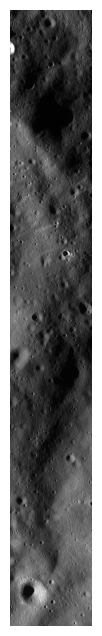

In [5]:
plt.figure(figsize=(12,8))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [8]:
DATA_ROOT = Path("../data/raw/tmc2/baseline")

img_path = (
    DATA_ROOT
    / "data"
    / "calibrated"
    / "20210401"
    / "ch2_ohr_ncp_20210401T2357376656_d_img_d18.img"
)

xml_path = img_path.with_suffix(".xml")

print("IMG exists:", img_path.exists())
print("XML exists:", xml_path.exists())
print("IMG:", img_path)

IMG exists: True
XML exists: True
IMG: ../data/raw/tmc2/baseline/data/calibrated/20210401/ch2_ohr_ncp_20210401T2357376656_d_img_d18.img


In [9]:
import xml.etree.ElementTree as ET

tree = ET.parse(xml_path)
root = tree.getroot()

# Print all XML elements containing useful image metadata
for elem in root.iter():
    tag = elem.tag.split("}")[-1]  # Remove XML namespace
    if elem.text and elem.text.strip():
        if tag in [
            "file_name",
            "file_size",
            "data_type",
            "axis_name",
            "elements",
            "pixel_resolution",
            "projection",
            "area"
        ]:
            print(f"{tag}: {elem.text.strip()}")

pixel_resolution: 0.26
projection: Selenographic
area: Equatorial
file_name: ch2_ohr_ncp_20210401T2357376656_d_img_d18.img
file_size: 1081776000
data_type: UnsignedByte
axis_name: Line
elements: 90148
axis_name: Sample
elements: 12000


In [10]:
ns = {
    "pds": "http://pds.nasa.gov/pds4/pds/v1"
}

axes = root.findall(".//pds:Axis_Array", ns)

dimensions = {}

for axis in axes:
    name = axis.find("pds:axis_name", ns).text
    elements = int(axis.find("pds:elements", ns).text)

    dimensions[name] = elements

print(dimensions)

{'Line': 90148, 'Sample': 12000}


In [13]:
lines = dimensions["Line"]
samples = dimensions["Sample"]

image = np.memmap(
    img_path,
    dtype=np.uint8,
    mode="r",
    shape=(lines, samples)
)

print(image.shape)
print(image.dtype)

(90148, 12000)
uint8


In [14]:
patch = image[50000:51000, 1500:2500]

print(patch.shape)
print("Min:", patch.min())
print("Max:", patch.max())
print("Mean:", patch.mean())

(1000, 1000)
Min: 23
Max: 225
Mean: 124.656669


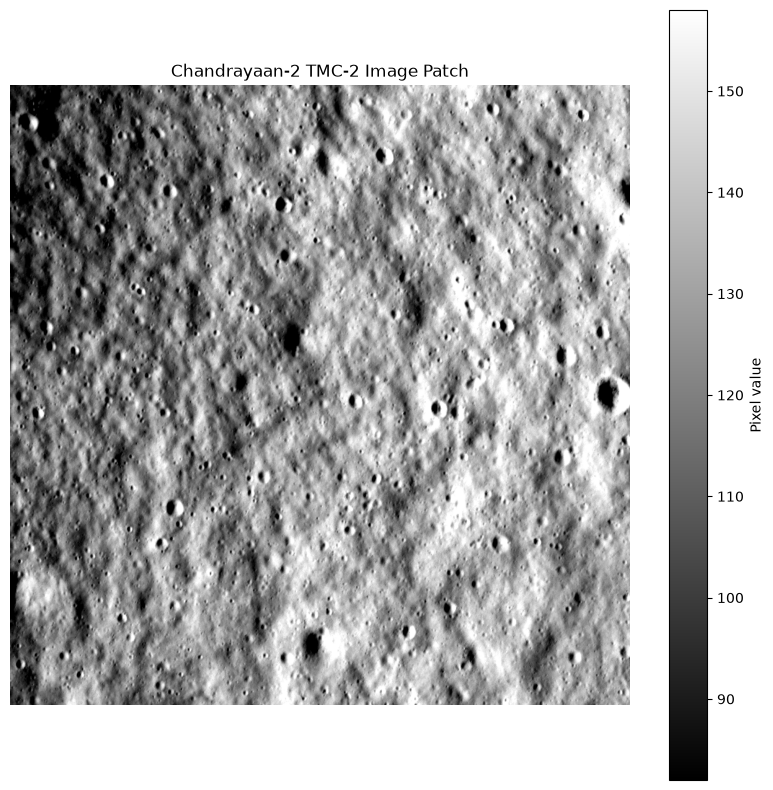

In [15]:
plt.figure(figsize=(10, 10))

plt.imshow(
    patch,
    cmap="gray",
    vmin=np.percentile(patch, 2),
    vmax=np.percentile(patch, 98)
)

plt.colorbar(label="Pixel value")
plt.title("Chandrayaan-2 TMC-2 Image Patch")
plt.axis("off")

plt.show()

In [16]:
vmin=np.percentile(patch, 2)
vmax=np.percentile(patch, 98)


In [17]:
print("Shape:", image.shape)
print("Dtype:", image.dtype)
print("Min:", image.min())
print("Max:", image.max())
print("Mean:", image.mean())
print("Std:", image.std())

Shape: (90148, 12000)
Dtype: uint8
Min: 0
Max: 255
Mean: 64.97243693056603
Std: 39.88276358553054


In [18]:
img = cv2.imread(str(BROWSE_IMAGE), cv2.IMREAD_UNCHANGED)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

Shape: (9014, 1200)
Dtype: uint8


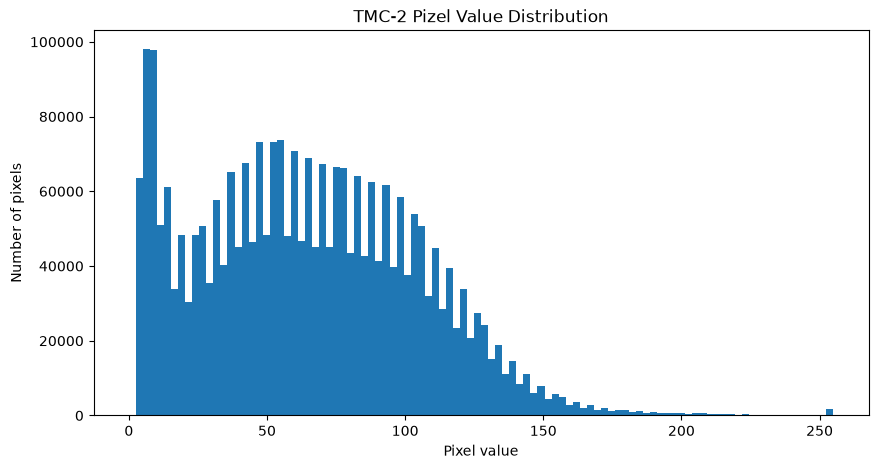

Zero pixels: 119
Zero percentage: 0.004399585921325052


In [19]:
sampled = image[::20, ::20]

plt.figure(figsize = (10,5))
plt.hist(
    sampled.ravel(),
    bins=100
)

plt.title("TMC-2 Pizel Value Distribution")
plt.xlabel("Pixel value")
plt.ylabel("Number of pixels")

plt.show()

print("Zero pixels:", np.sum(sampled ==0))
print("Zero percentage:", 100*np.mean(sampled ==0))

In [20]:
for p in [0, 1, 2, 5, 25, 50, 75, 95, 98, 99, 100]:
    print(f"{p:>3}%: {np.percentile(sampled, p):.2f}")

  0%: 0.00
  1%: 5.00
  2%: 5.00
  5%: 7.00
 25%: 34.00
 50%: 63.00
 75%: 93.00
 95%: 131.00
 98%: 148.00
 99%: 163.00
100%: 255.00


In [21]:
geometry_dir = (
    DATA_ROOT
    / "geometry"
    / "calibrated"
    / "20210401"
)

csv_path = next(geometry_dir.glob("*.csv"))
geom_xml_path = next(geometry_dir.glob("*.xml"))

print("CSV:", csv_path)
print("XML:", geom_xml_path)

CSV: ../data/raw/tmc2/baseline/geometry/calibrated/20210401/ch2_ohr_ncp_20210401T2357376656_g_grd_d18.csv
XML: ../data/raw/tmc2/baseline/geometry/calibrated/20210401/ch2_ohr_ncp_20210401T2357376656_g_grd_d18.xml


In [22]:
import pandas as pd

geo_df = pd.read_csv(csv_path)

print("Shape:", geo_df.shape)
display(geo_df.head())
print("\nColumns:")
print(geo_df.columns.tolist())

Shape: (109263, 4)


,Longitude,Latitude,Pixel,Scan
0,25.133115,-13.058433,0,0
1,25.134061,-13.058407,100,0
2,25.135006,-13.058381,200,0
3,25.135951,-13.058355,300,0
4,25.136896,-13.058329,400,0



Columns:
['Longitude', 'Latitude', 'Pixel', 'Scan']


In [26]:
print("Pixel range:")
print(geo_df["Pixel"].min(), geo_df["Pixel"].max())

print("\nScan range:")
print(geo_df["Scan"].min(), geo_df["Scan"].max())

print("\nUnique pixels:")
print(sorted(geo_df["Pixel"].unique())[:20])

print("\nRows for Pixel = 0:")
print(geo_df[geo_df["Pixel"] == 0].head(10))

Pixel range:
0 11999

Scan range:
0 90147

Unique pixels:
[np.int64(0), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000), np.int64(1100), np.int64(1200), np.int64(1300), np.int64(1400), np.int64(1500), np.int64(1600), np.int64(1700), np.int64(1800), np.int64(1900)]

Rows for Pixel = 0:
      Longitude   Latitude  Pixel  Scan
0     25.133115 -13.058433      0     0
121   25.133109 -13.059354      0   100
242   25.133103 -13.060276      0   200
363   25.133097 -13.061197      0   300
484   25.133091 -13.062119      0   400
605   25.133085 -13.063040      0   500
726   25.133079 -13.063960      0   600
847   25.133074 -13.064880      0   700
968   25.133069 -13.065800      0   800
1089  25.133064 -13.066720      0   900


In [28]:
print("Longitude range:")
print(
    geo_df["Longitude"].min(),
    geo_df["Longitude"].max()
)

print("\nLatitude range:")
print(
    geo_df["Latitude"].min(),
    geo_df["Latitude"].max()
)

print("\nCorner coordinates:")
for scan, pixel in [
    (0, 0),
    (0, 3999),
    (148107, 0),
    (148107, 3999)
]:
    row = geo_df[
        (geo_df["Scan"] == scan) &
        (geo_df["Pixel"] == pixel)
    ]

    print(f"\nScan={scan}, Pixel={pixel}")
    display(row)

Longitude range:
25.1284216 25.2459116

Latitude range:
-13.8889155 -13.055345

Corner coordinates:

Scan=0, Pixel=0


,Longitude,Latitude,Pixel,Scan
0,25.133115,-13.058433,0,0



Scan=0, Pixel=3999


,Longitude,Latitude,Pixel,Scan



Scan=148107, Pixel=0


,Longitude,Latitude,Pixel,Scan



Scan=148107, Pixel=3999


,Longitude,Latitude,Pixel,Scan
